In [1]:
import requests
import json
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
from utils import sample_to_img,extract_boundaries

In [2]:
instruction =json.loads("""
{
"control_matrix": 
[[5.0, 0.0, 0.0, 1.0, 0.0, 0.0], 
 [0.0, 12.0, 0.0, 1.0, 0.0, 0.0], 
 [0.0, 0.0, 12.0, 1.0, 0.0, 0.0], 
 [1.0, 1.0, 1.0, 5.0, 0.0, 1.0], 
 [0.0, 0.0, 0.0, 0.0, 9.0, 1.0], 
 [0.0, 0.0, 0.0, 1.0, 1.0, 18.0]], 
"geometries": [null, null, null, null, null,null, [[0.73, 3.64], [1.88, -0.59], [5.91, 0.23], [4.76, 4.53]]], 
"aspect_ratios": ["NaN", "NaN", "NaN", "NaN", "NaN", "NaN"], 
"colours": [[0.0, 0.0, 255.0], [74.0, 184.0, 0.0], [145.0, 234.0, 0.0], [255.0, 126.0, 255.0], [255.0, 0.0, 0.0], [247.0, 255.0, 0.0]],
"lock_trans": [true,true,true,true,true,true]
}
""")
instruction

{'control_matrix': [[5.0, 0.0, 0.0, 1.0, 0.0, 0.0],
  [0.0, 12.0, 0.0, 1.0, 0.0, 0.0],
  [0.0, 0.0, 12.0, 1.0, 0.0, 0.0],
  [1.0, 1.0, 1.0, 5.0, 0.0, 1.0],
  [0.0, 0.0, 0.0, 0.0, 9.0, 1.0],
  [0.0, 0.0, 0.0, 1.0, 1.0, 18.0]],
 'geometries': [None,
  None,
  None,
  None,
  None,
  None,
  [[0.73, 3.64], [1.88, -0.59], [5.91, 0.23], [4.76, 4.53]]],
 'aspect_ratios': ['NaN', 'NaN', 'NaN', 'NaN', 'NaN', 'NaN'],
 'colours': [[0.0, 0.0, 255.0],
  [74.0, 184.0, 0.0],
  [145.0, 234.0, 0.0],
  [255.0, 126.0, 255.0],
  [255.0, 0.0, 0.0],
  [247.0, 255.0, 0.0]],
 'lock_trans': [True, True, True, True, True, True]}

In [ ]:
key = "API_KEY"
result = requests.post("https://jair.app/inference",headers = {f"api-key": key},json=instruction)

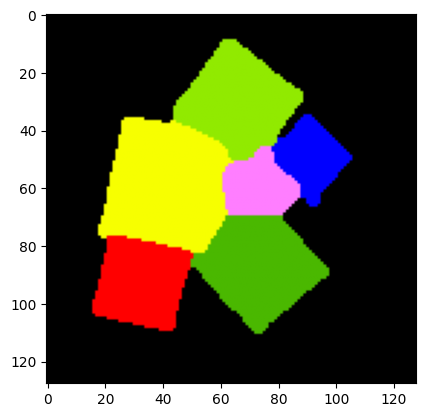

In [15]:
num_samples = int(result.headers['num_samples'])
imsize = int(result.headers['imsize'])

arr = np.frombuffer(result.content[:(num_samples*imsize**2)], dtype=np.uint8).reshape(num_samples,imsize,imsize)[:,::-1]
transformations = np.frombuffer(result.content[(num_samples*imsize**2):],dtype=np.float32).reshape(num_samples,-1,3)

scale = 1/(1440/np.array(instruction['control_matrix']).diagonal().sum())**.5*(64/imsize)

N = arr.max() + 1  # number of layers

index = np.random.randint(0,arr.shape[0])

arr = np.pad(arr[index],pad_width=((0,1), (0,1)),mode='constant',constant_values=N-1)
H, W = arr.shape
#onehot
onehot = np.zeros((N, H, W), dtype=np.uint8)
rows = np.arange(H)[:, None]
cols = np.arange(W)
onehot[arr, rows, cols] = 1

plt.imshow(sample_to_img(onehot[:-1,:-1,:-1],instruction['colours']))

In [355]:
#generate boundary geometry and masks
edges,adjacencies = extract_boundaries(onehot,2.5)
#find offset relative to control geometries
mask = onehot[:-1] > 0
x_any = mask.any(axis=1)        # (N, H)
y_any = mask.any(axis=2)        # (N, W)
xmin = np.argmax(x_any, axis=1)
xmax = x_any.shape[1] - 1 - np.argmax(x_any[:, ::-1], axis=1)
ymin = np.argmax(y_any, axis=1)
ymax = y_any.shape[1] - 1 - np.argmax(y_any[:, ::-1], axis=1)
means = -np.stack([((xmin+xmax)/2),((ymin+ymax)/2)],axis=1)*scale
if instruction['geometries'][0] == None:
    offsets = []
    for mean,geom in zip(means,instruction['geometries'][1:]):
        if geom !=None:
            geom = np.array(geom)
            offsets.append(mean-((geom.max(0)+geom.min(0)))/2)
    if len(offsets)>0:
        offsets = np.stack(offsets)
        offset = offsets.mean(0)
    else:
        offset = [-32*scale,-32*scale]
else:
    geom = np.array(instruction['geometries'][0])
    offset = means[0]-((geom.max(0)+geom.min(0)))/2

edges = [np.array(edge) -offset for edge in edges]